In [3]:
import functions
import importlib
from matplotlib import pyplot as plt
import cv2
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
importlib.reload(functions)
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [4]:
imagens, imgs_mask, labels = functions.load_and_resize_images()

Total de imagens: 1023
Total de labels: 1023


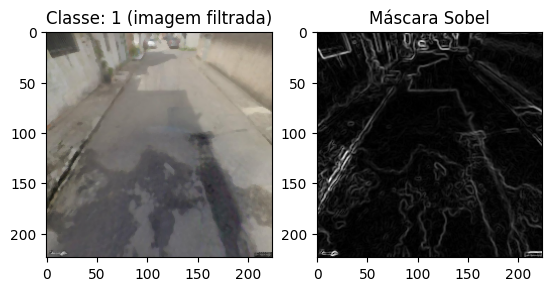

In [5]:
i = 500 # exemplo
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB))
plt.title(f"Classe: {labels[i]} (imagem filtrada)")

plt.subplot(1,2,2)
plt.imshow(imgs_mask[i].squeeze(), cmap="gray")
plt.title("Máscara Sobel")
plt.show()


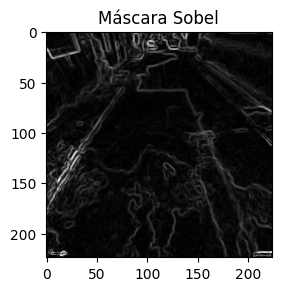

In [6]:
imgs_mask_thresh = []
for mask in imgs_mask:
    sobel_norm = cv2.normalize(mask, None, 0, 255, cv2.NORM_MINMAX)
    imgs_mask_thresh.append(sobel_norm)

imgs_mask_thresh = np.array(imgs_mask_thresh)

plt.subplot(1,2,2)
plt.imshow(imgs_mask_thresh[i].squeeze(), cmap="gray")
plt.title("Máscara Sobel")
plt.show()

In [7]:
# --- Normalização ---
X_imgs = np.array(imagens) / 255.0
X_masks = np.array(imgs_mask_thresh) / 255.0
X_masks = np.expand_dims(X_masks, axis=-1)

# --- Labels ---
y = np.array(labels)

# --- 1. Undersampling para balancear ---
classes = np.unique(y)
min_count = min([np.sum(y == c) for c in classes])

X_img_bal = []
X_mask_bal = []
y_bal = []

for c in classes:
    idx = np.where(y == c)[0]
    np.random.shuffle(idx)
    idx_cut = idx[:min_count]  # corta para o mínimo
    X_img_bal.append(X_imgs[idx_cut])
    X_mask_bal.append(X_masks[idx_cut])
    y_bal.append(y[idx_cut])

# Concatenar tudo
X_imgs = np.concatenate(X_img_bal, axis=0)
X_masks = np.concatenate(X_mask_bal, axis=0)
y = np.concatenate(y_bal, axis=0)

# --- 2. One-hot após balancear ---
y = to_categorical(y, num_classes=3)

# --- 3. Divisão treino/val/test ---
X_img_train, X_img_test, X_mask_train, X_mask_test, y_train, y_test = train_test_split(
    X_imgs, X_masks, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)

X_img_train, X_img_val, X_mask_train, X_mask_val, y_train, y_val = train_test_split(
    X_img_train, X_mask_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1)
)

In [8]:
# Entrada da imagem RGB
input_img = Input(shape=(X_imgs.shape[1], X_imgs.shape[2], 3))

x1 = Conv2D(16, (3,3), activation='relu')(input_img)
x1 = MaxPooling2D((2,2))(x1)
x1 = Conv2D(8, (3,3), activation='relu')(x1)
x1 = MaxPooling2D((2,2))(x1)
x1 = Flatten()(x1)

# Entrada da máscara (1 canal)
input_mask = Input(shape=(X_masks.shape[1], X_masks.shape[2], 1))

x2 = Conv2D(16, (3,3), activation='relu')(input_mask)
x2 = MaxPooling2D((2,2))(x2)
x2 = Conv2D(8, (3,3), activation='relu')(x2)
x2 = MaxPooling2D((2,2))(x2)
x2 = Flatten()(x2)

# Concatenar as duas saídas
merged = Concatenate()([x1, x2])

# Classificação final
dense = Dense(64, activation='relu')(merged)
dense = Dropout(0.5)(dense)
output = Dense(3, activation='softmax')(dense)

# Modelo final
model = Model(inputs=[input_img, input_mask], outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 222, 222,  │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 111,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 111, 111,  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      1,160 │ max_pooling2d[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 109, 109,  │      1,160 │ max_pooling2d_2[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 54, 54, 8) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 54, 54, 8) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 23328)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 23328)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 46656)     │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  2,986,048 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,989,171 (11.40 MB)

 Trainable params: 2,989,171 (11.40 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Callback para salvar o melhor modelo baseado na acurácia de validação
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',   # nome do arquivo
    monitor='val_accuracy',     # métrica a ser monitorada
    mode='max',                 # queremos o maior valor de acurácia
    save_best_only=True,        # salva apenas o melhor
    verbose=0
)

# Treinamento com callback
history = model.fit(
    [X_img_train, X_mask_train],
    y_train,
    validation_data=([X_img_val, X_mask_val], y_val),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint],  # adiciona aqui
    verbose=1
)

loss, acc = model.evaluate([X_img_test, X_mask_test], y_test)
print(f"Test Accuracy: {acc:.2f}")

Epoch 1/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3436 - loss: 1.4123

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 0.3629 - loss: 1.2552 - val_accuracy: 0.5263 - val_loss: 0.9972
Epoch 2/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5323 - loss: 0.9642

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5482 - loss: 0.9408 - val_accuracy: 0.5414 - val_loss: 0.8940
Epoch 3/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5876 - loss: 0.8523

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.6011 - loss: 0.8359 - val_accuracy: 0.6090 - val_loss: 0.8288
Epoch 4/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6720 - loss: 0.7152

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.6427 - loss: 0.7497 - val_accuracy: 0.6767 - val_loss: 0.7722
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7183 - loss: 0.6528 - val_accuracy: 0.6165 - val_loss: 0.7798
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7449 - loss: 0.5996

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.7448 - loss: 0.6013 - val_accuracy: 0.7368 - val_loss: 0.6933
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8034 - loss: 0.4754 - val_accuracy: 0.6917 - val_loss: 0.7403
Epoch 8/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8040 - loss: 0.4877

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.8166 - loss: 0.4532 - val_accuracy: 0.7820 - val_loss: 0.6714
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8544 - loss: 0.3813 - val_accuracy: 0.7293 - val_loss: 0.7535
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8847 - loss: 0.2926 - val_accuracy: 0.7519 - val_loss: 0.6736
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9263 - loss: 0.2165 - val_accuracy: 0.6992 - val_loss: 0.9762
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9319 - loss: 0.1979 - val_accuracy: 0.7519 - val_loss: 0.7688
Epoch 13/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9208 - loss: 0.2167

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9301 - loss: 0.1930 - val_accuracy: 0.7970 - val_loss: 0.8057
Epoch 14/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9301 - loss: 0.1592 - val_accuracy: 0.7218 - val_loss: 0.7666
Epoch 15/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9395 - loss: 0.1623 - val_accuracy: 0.7519 - val_loss: 0.8353
Epoch 16/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9584 - loss: 0.1288 - val_accuracy: 0.7594 - val_loss: 0.8596
Epoch 17/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9584 - loss: 0.1082 - val_accuracy: 0.7820 - val_loss: 1.0513
Epoch 18/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9546 - loss: 0.1018 - val_accuracy: 0.7218 - val_loss: 0.8407
Epoch 19/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9754 - loss: 0.0830 - val_accuracy: 0.7519 - val_loss: 0.9757
Epoch 20/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9698 - loss: 0.0711 - val_accuracy: 0.7143 - val_

In [10]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5')

loss, acc = best_model.evaluate([X_img_test, X_mask_test], y_test)
print(f"Best Model Test Accuracy: {acc:.2f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8012 - loss: 0.6185
Best Model Test Accuracy: 0.80


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


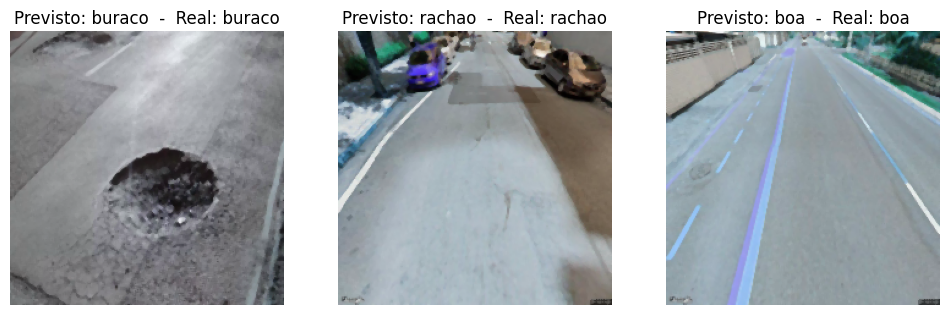

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
class_names = ["buraco", "rachao", "boa"]

# Seleciona uma imagem aleatória de cada classe
indices = []
for c in range(3):
    idxs = np.where(np.argmax(y_test, axis=1) == c)[0]
    idx = np.random.choice(idxs)  # escolha aleatória
    indices.append(idx)

# Loop para plotar
plt.figure(figsize=(12,4))

for i, idx in enumerate(indices):
    img = X_img_test[idx]
    label = y_test[idx]
    if label[0] == 1:
        label = "buraco"
    elif label[1] == 1:
        label = "rachao"
    else:
        label = "boa"
    mask = X_mask_test[idx][..., 0]  # pega canal único da máscara

    # Predição do modelo
    pred = best_model.predict([img[np.newaxis,...], X_mask_test[idx][np.newaxis,...]])
    pred_class = class_names[np.argmax(pred)]

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Previsto: {pred_class}  -  Real: {label}")
    plt.axis('off')


plt.show()


